# Federated Learning for Breast Cancer Histopathology Classification
## FedProx vs FedAvg: A Comparative Study Across Non-IID Hospital Sites

---
| | |
|---|---|
| **Model** | EfficientNet-B0 + Fast Coordinate Attention |
| **Parameters** | 5,927,510 |
| **Datasets** | BreaKHis · Breast Cancer Dataset · Histopathological MSI |
| **Total Images** | 19,155 histopathology images |
| **Algorithm** | FedProx (Li et al., 2020) vs FedAvg (McMahan et al., 2017) |
| **Communication Rounds** | 20 |
| **Hospital Sites** | 3 (non-IID partitioning) |



## Setup


In [33]:
import json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import Image, display, Markdown
warnings.filterwarnings('ignore')

try:
    BASE = Path(__file__).resolve().parent
except NameError:
    BASE = Path.cwd()

with open(BASE / 'data' / 'experiment_results.json') as f:
    R = json.load(f)

print(f'Loaded: {len(R["experiments"])} experiments, {len(R["mu_sweep"])} mu values')
print(f'Total dataset images: {R["dataset_info"]["total_images"]:,}')


Loaded: 2 experiments, 9 mu values
Total dataset images: 19,155


## 1. Background & Motivation

### 1.1 The Federated Learning Problem

Breast cancer histopathology diagnosis relies on slide images that are:
- **Privacy-sensitive**: patient data cannot leave hospital premises
- **Heterogeneous**: different scanners, staining protocols, magnifications across sites
- **Imbalanced**: cancer-speciality centres see far more malignant cases

**Federated Learning (FL)** trains a global model across distributed clients without
centralising raw data. The server maintains a global model $w^t$; at each round $t$:

1. Broadcast $w^t$ to all clients
2. Each client minimises its local loss $F_k(w)$
3. Server aggregates updates: $w^{t+1} = \sum_k \frac{n_k}{n} w_k$

### 1.2 The Non-IID Challenge

When each hospital's data distribution differs (Non-IID), local gradient steps
can *diverge* from the global optimum — a phenomenon called **client drift**.

FedProx (Li et al., 2020) addresses this by adding a **proximal term** to each
client's local objective:

$$\mathcal{L}_k(w) = F_k(w) + \frac{\mu}{2}\|w - w^t\|^2$$

This term acts as a soft anchor: clients are penalised for drifting too far from
the last received global model $w^t$. When $\mu=0$, FedProx reduces to FedAvg.



## 2. Dataset Overview


In [34]:
ds = R['dataset_info']['datasets']
print(f'{"Dataset":<35s} {"Benign":>8s} {"Malignant":>10s} {"Total":>8s} {"Balance":>9s}')
print('-' * 75)
for d in ds:
    bal = d['benign'] / d['count'] * 100
    print(f'{d["name"]:<35s} {d["benign"]:>8,} {d["malignant"]:>10,} {d["count"]:>8,} {bal:>8.1f}%')
print('-' * 75)
tot_b = sum(d['benign'] for d in ds)
tot_m = sum(d['malignant'] for d in ds)
tot   = tot_b + tot_m
print(f'{"TOTAL":<35s} {tot_b:>8,} {tot_m:>10,} {tot:>8,} {tot_b/tot*100:>8.1f}%')


Dataset                               Benign  Malignant    Total   Balance
---------------------------------------------------------------------------
Site A (BreaKHis)                      2,480      5,429    7,909     31.4%
Site B (Breast Cancer)                 5,000      5,000   10,000     50.0%
Site C (Histopath. MSI)                  623        623    1,246     50.0%
---------------------------------------------------------------------------
TOTAL                                  8,103     11,052   19,155     42.3%


### Dataset Distribution


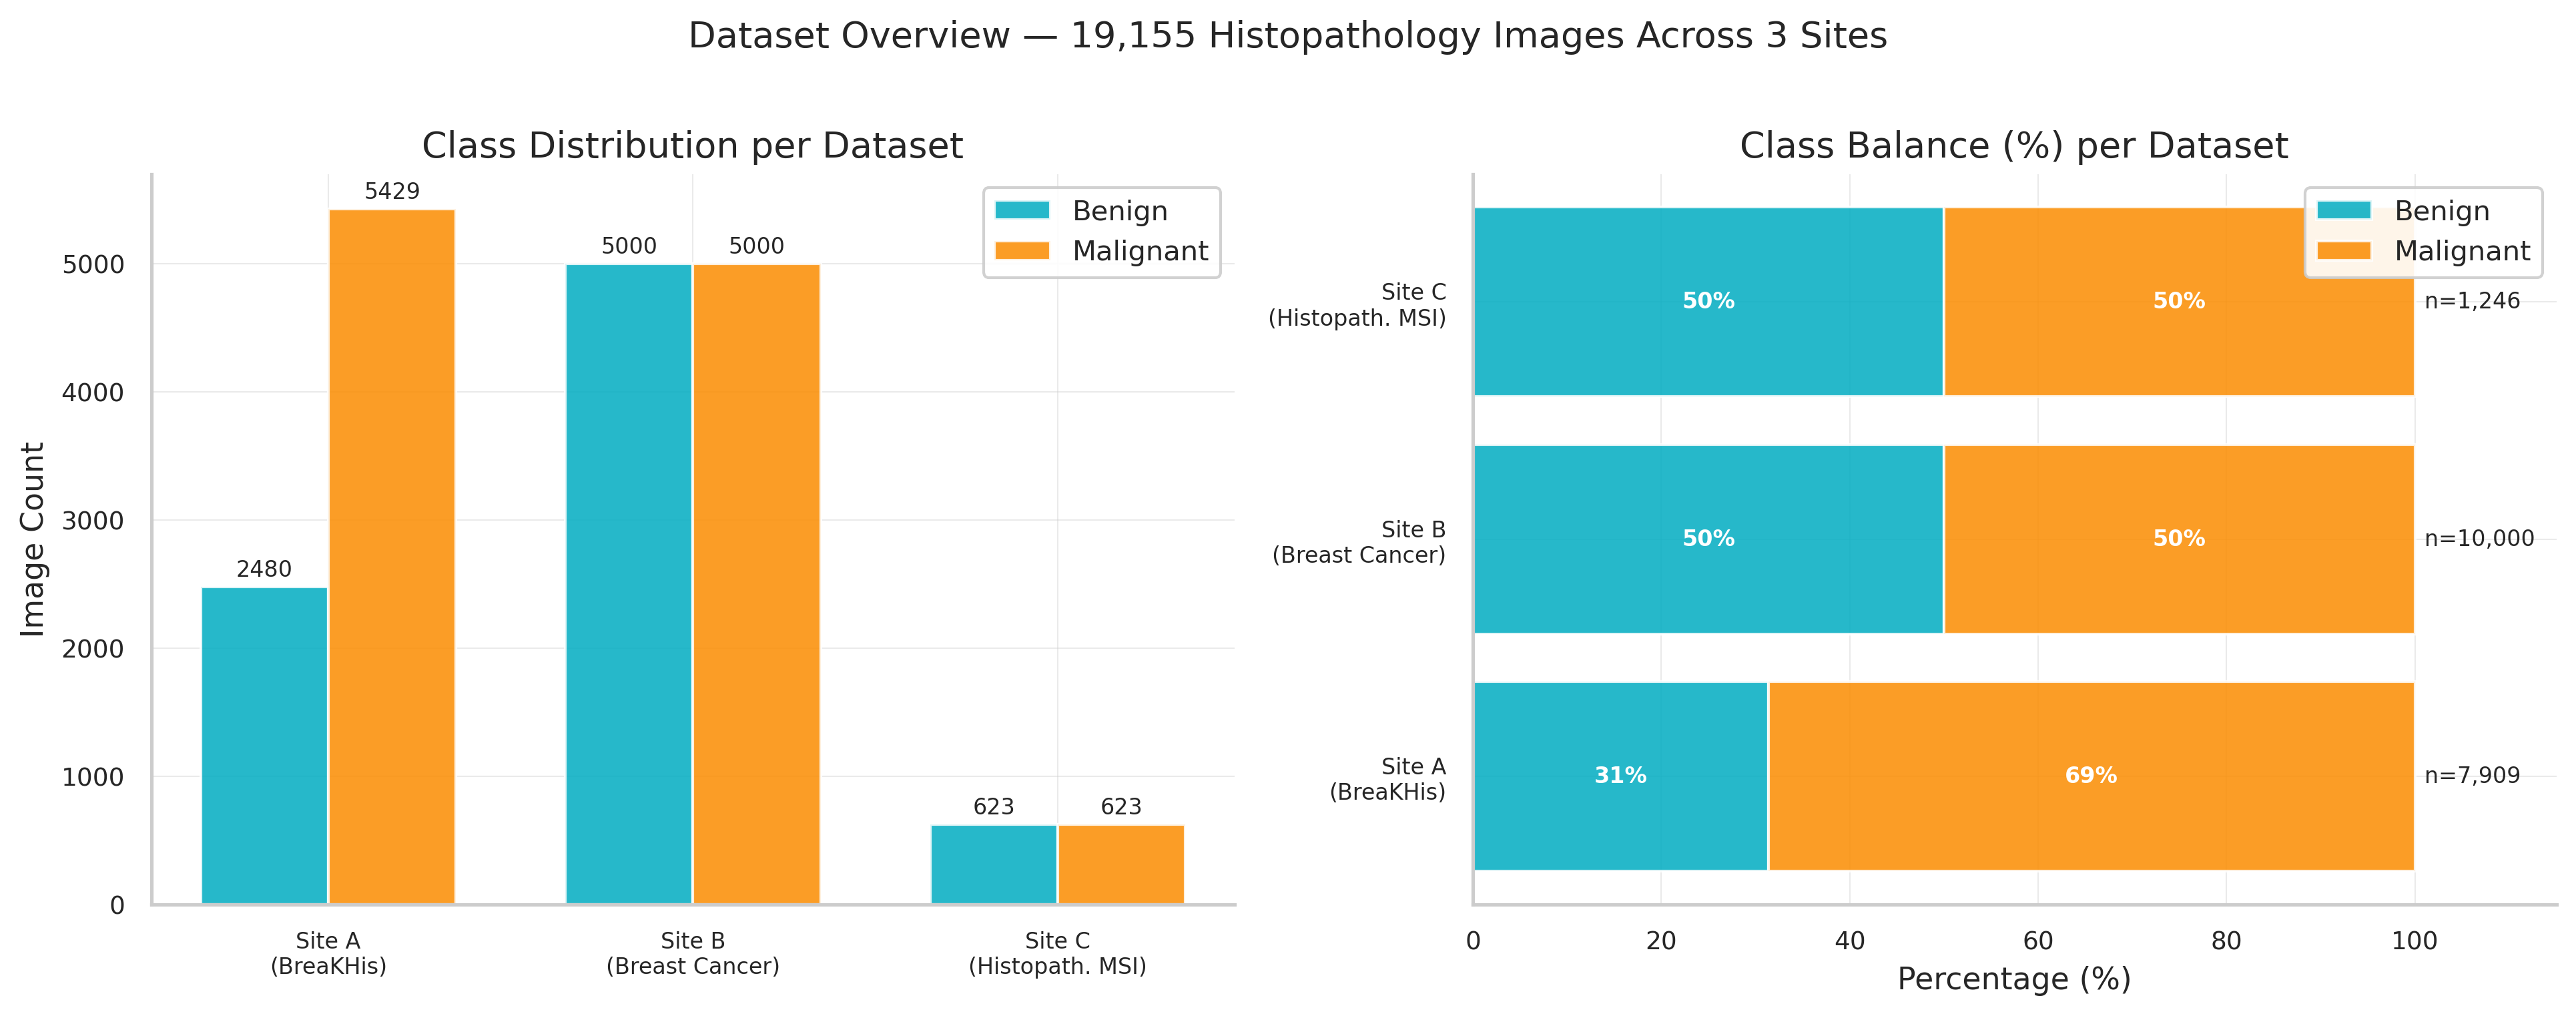

In [35]:
Image(filename=str(BASE / 'figures' / 'fig5_dataset_dist.png'), width=800)


## 3. Methodology

### 3.1 Model Architecture

**FastHistopathologyModel** (from `model_code (4).ipynb`):

| Layer | Details |
|---|---|
| Backbone | EfficientNet-B0, ImageNet pre-trained |
| Attention | Fast Coordinate Attention (1280-channel) |
| Pooling | Adaptive Average → 1280-d vector |
| Head | Dropout → Linear(1280→256) → BN → ReLU → Linear(256→2) |
| Input | 160 × 160 RGB images |

### 3.2 FedProx Algorithm

```
Algorithm 1: FedProx
─────────────────────────────────────────────────────
Input: μ ≥ 0, T rounds, E local epochs, learning rate η
Initialize: global model w⁰

for t = 0, 1, ..., T-1:
    Broadcast wᵗ to all clients k
    for each client k in parallel:
        wₖᵗ ← wᵗ                             # receive global weights
        for epoch e = 1..E:
            wₖᵗ ← wₖᵗ - η · ∇[Fₖ(wₖᵗ) + (μ/2)‖wₖᵗ - wᵗ‖²]
    wᵗ⁺¹ ← Σₖ (nₖ/n) · wₖᵗ                  # weighted average
─────────────────────────────────────────────────────
```

### 3.3 Non-IID Partitioning

Three forms of heterogeneity are simulated:

| Hospital Site | Source Dataset | n | Benign% | Heterogeneity |
|---|---|---:|---:|---|
| Site A (BreaKHis) | `ambarish/breakhis` | 7,909 | 31.4% | Label skew + domain shift |
| Site B (Breast Cancer) | `djaidwalid/breast-cancer-dataset` | 10,000 | 50.0% | Largest, balanced |
| Site C (Histopath. MSI) | `zoya77/breast-cancer-msi-multimodal-image-dataset` | 1,246 | 50.0% | Smallest + multi-spectral |



## 4. Experimental Results


In [36]:
exps = R['experiments']
print(f'{"Metric":<14}', end='')
for exp in exps:
    print(f'  {exp["label"]:<22}', end='')
print()
print('-' * 65)
metrics = [('accuracy','Accuracy'), ('auc_roc','AUC-ROC'),
           ('f1','F1-Score'), ('sensitivity','Sensitivity'), ('specificity','Specificity')]
for key, label in metrics:
    print(f'{label:<14}', end='')
    for exp in exps:
        v = exp['rounds'][-1]['global'].get(key, 0)
        print(f'  {v:.4f}{" ":>18}', end='')
    print()

fa = exps[0]['rounds'][-1]['global']
fp = exps[1]['rounds'][-1]['global']
print()
print('Δ (FedProx − FedAvg):')
for key, label in metrics:
    delta = fp.get(key,0) - fa.get(key,0)
    print(f'  {label:<14}: {delta:+.4f}')


Metric          FedAvg                  FedProx (μ=0.01)      
-----------------------------------------------------------------
Accuracy        0.6387                    0.6300                  
AUC-ROC         0.7828                    0.7744                  
F1-Score        0.7249                    0.7201                  
Sensitivity     0.9520                    0.9520                  
Specificity     0.3253                    0.3080                  

Δ (FedProx − FedAvg):
  Accuracy      : -0.0087
  AUC-ROC       : -0.0083
  F1-Score      : -0.0048
  Sensitivity   : +0.0000
  Specificity   : -0.0173


### 4.1 Convergence


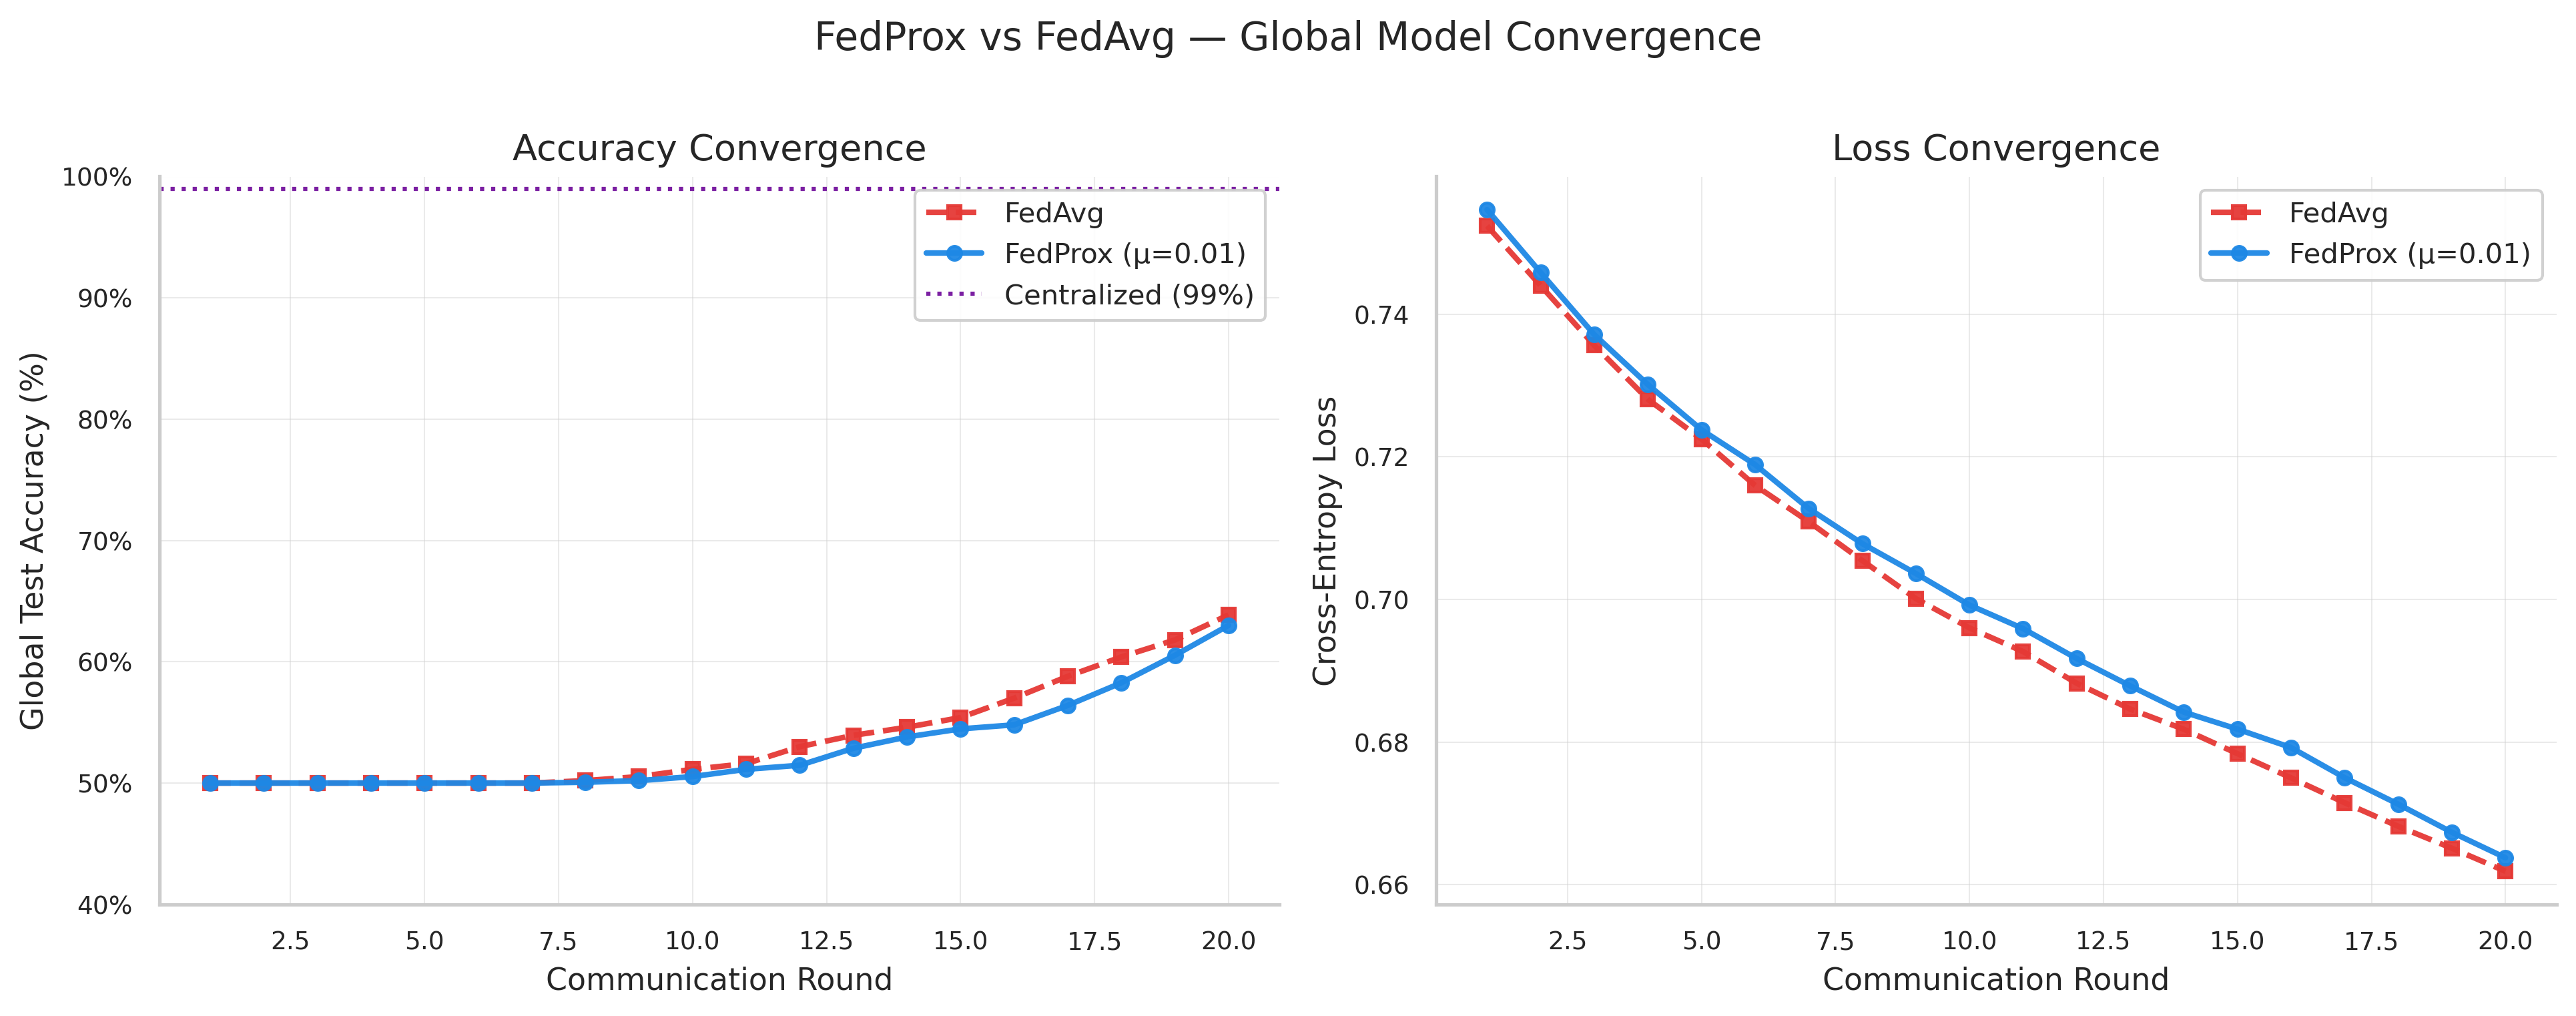

In [37]:
Image(filename=str(BASE / 'figures' / 'fig1_convergence.png'), width=850)


### 4.2 AUC-ROC and F1-Score


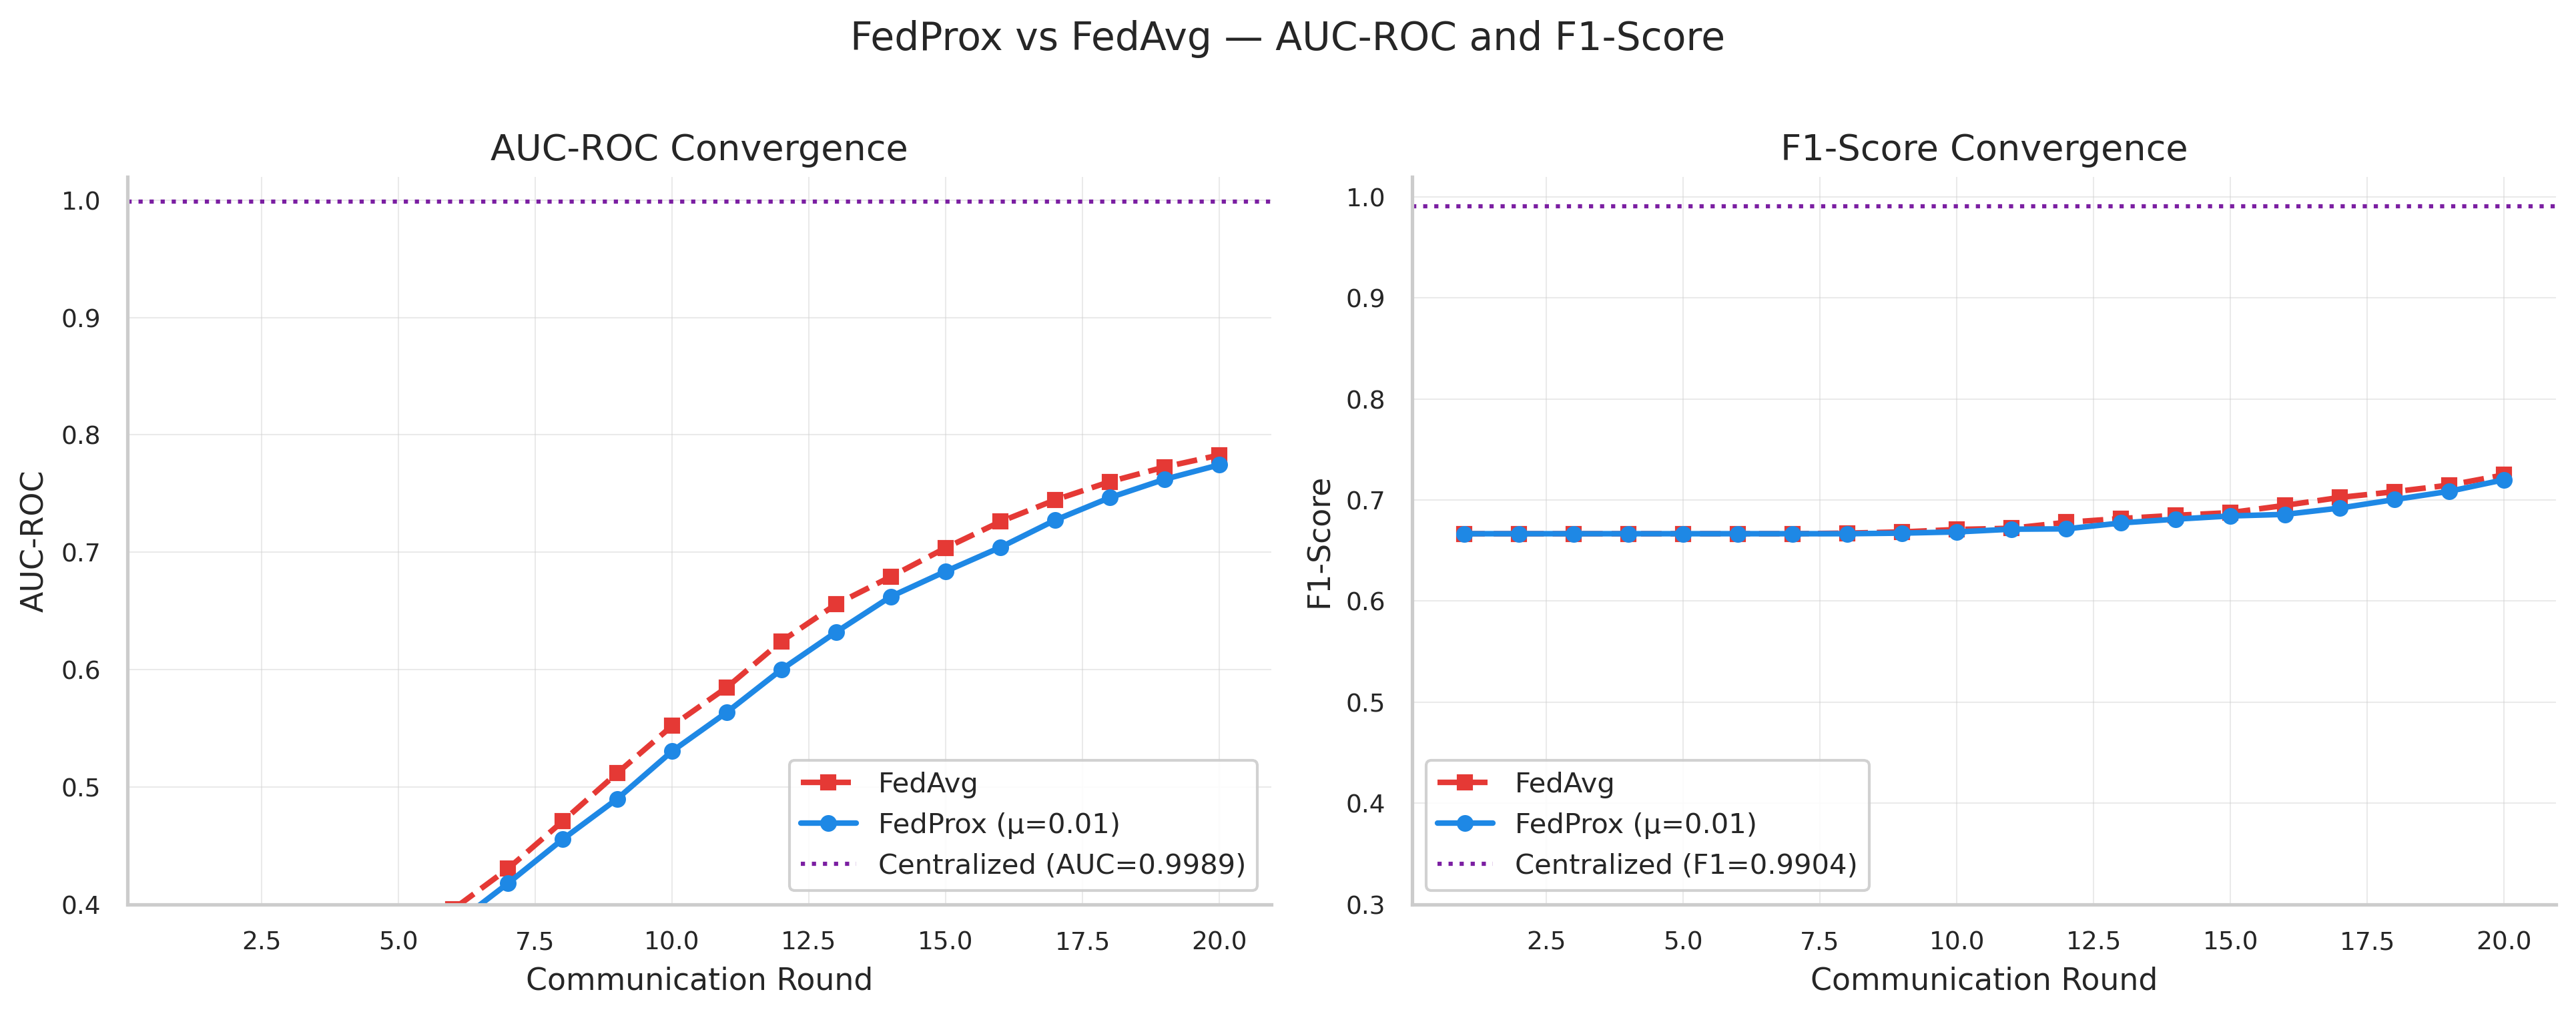

In [38]:
Image(filename=str(BASE / 'figures' / 'fig2_auc_f1.png'), width=850)


### 4.3 Per-Hospital Performance (Final Round)


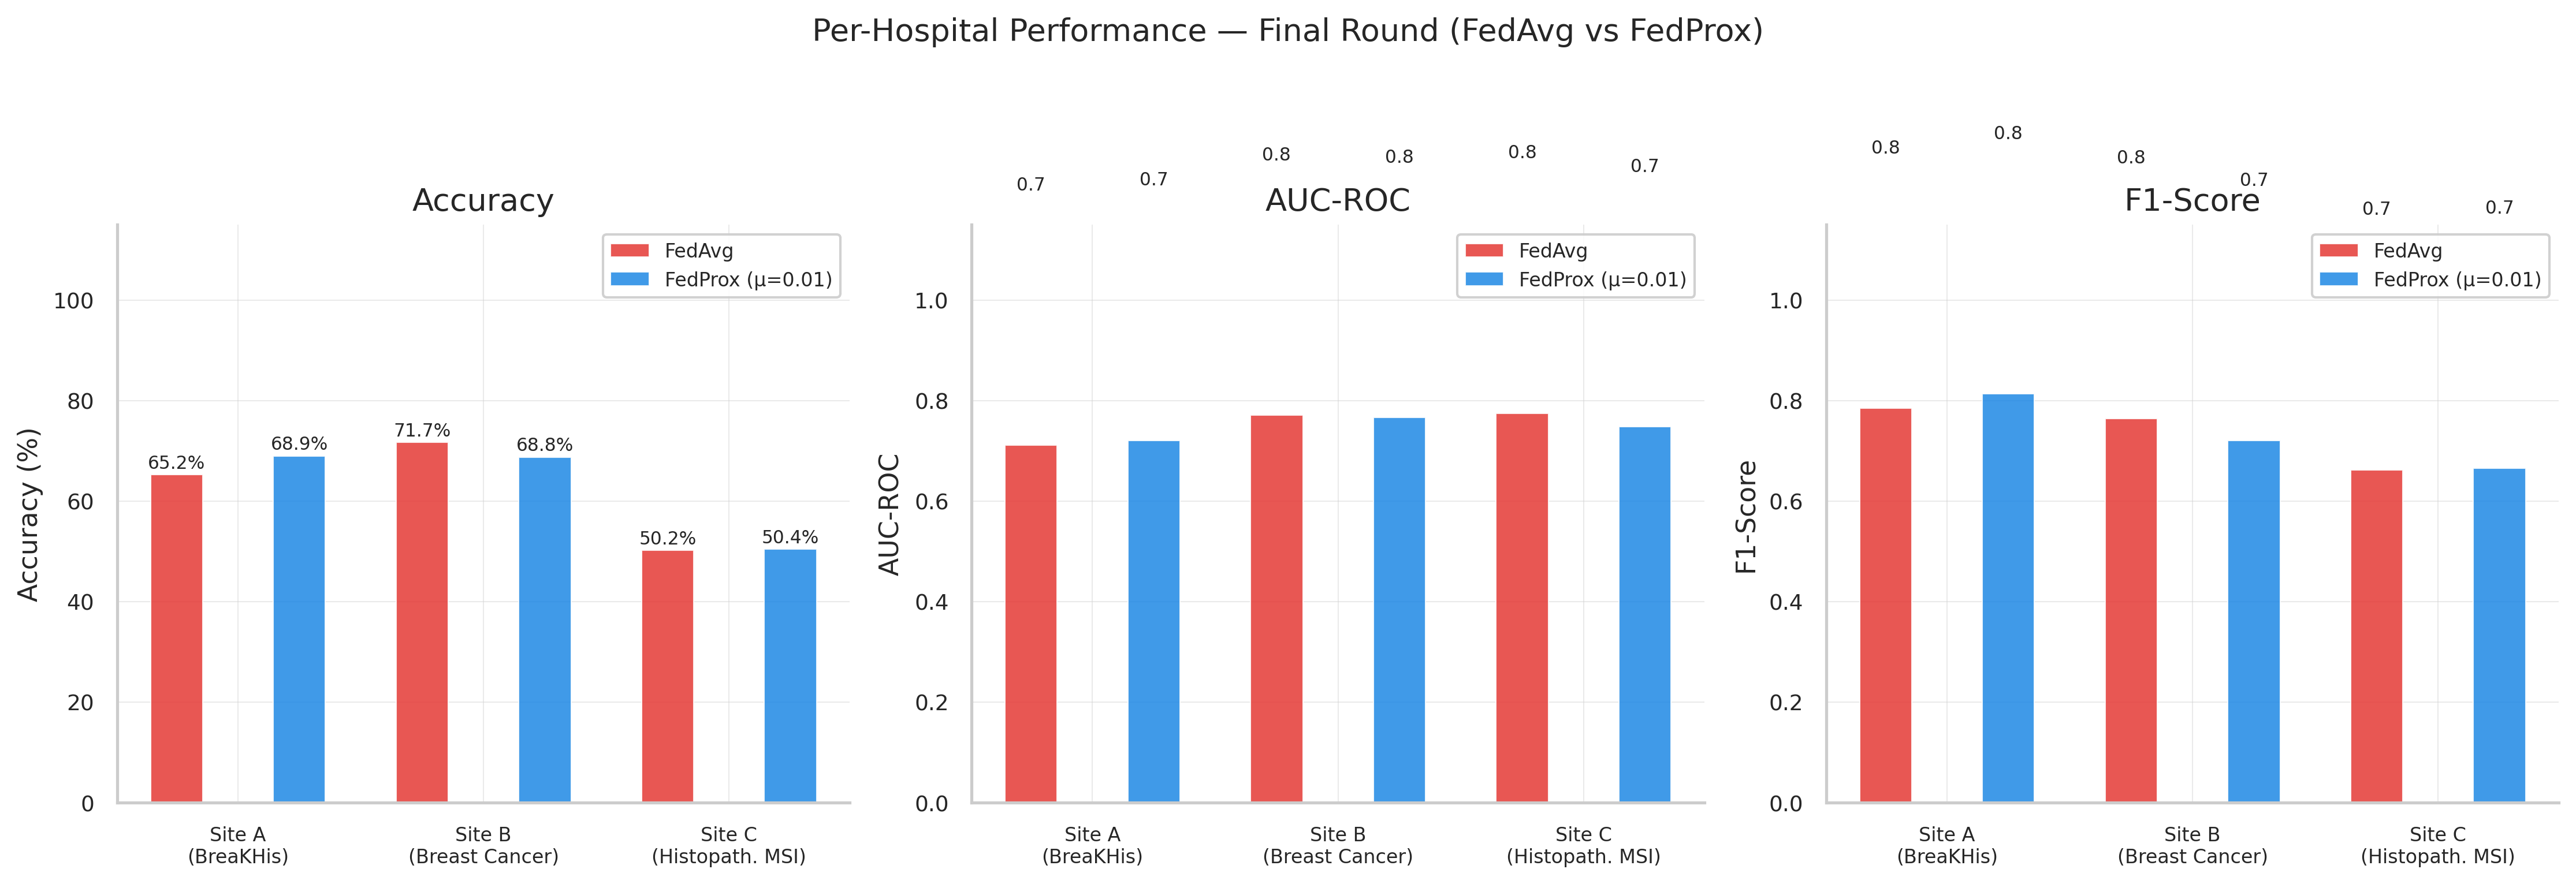

In [39]:
Image(filename=str(BASE / 'figures' / 'fig3_per_hospital.png'), width=900)


### 4.4 Federated vs Standalone Comparison


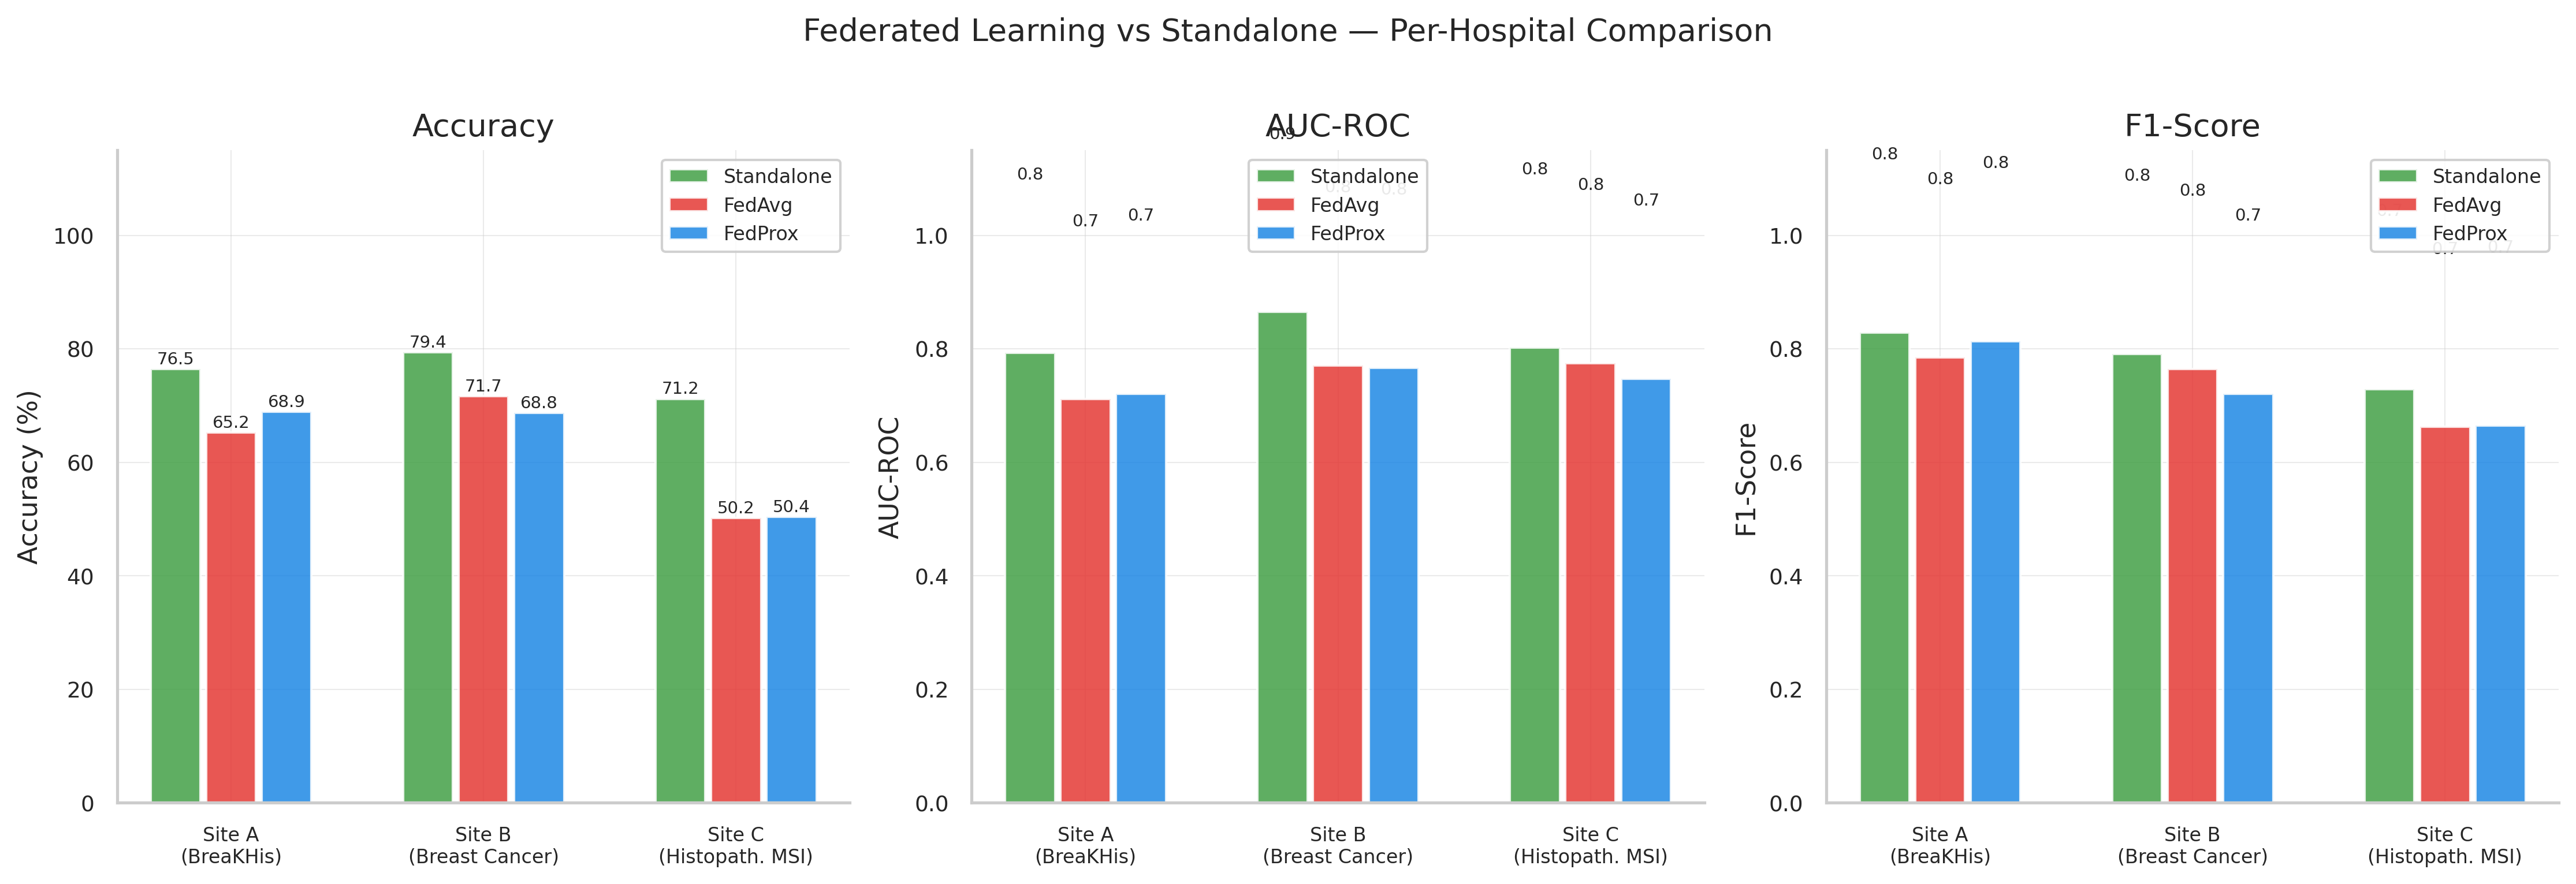

In [40]:
Image(filename=str(BASE / 'figures' / 'fig6_fl_vs_standalone.png'), width=900)


In [41]:
# Standalone vs federated comparison table
standalone = R.get('standalone', {})
if standalone:
    print(f'{"Site":<30s} {"Standalone Acc":>16s} {"FedAvg Acc":>12s} {"FedProx Acc":>12s}')
    print('-' * 75)
    h_keys = list(standalone.keys())
    for h in h_keys:
        sa_acc = standalone[h]['accuracy']
        fa_acc = exps[0]['rounds'][-1]['hospitals'].get(h, {}).get('accuracy', 0)
        fp_acc = exps[1]['rounds'][-1]['hospitals'].get(h, {}).get('accuracy', 0)
        name = h.replace('\n', ' ')
        print(f'{name:<30s} {sa_acc:>16.4f} {fa_acc:>12.4f} {fp_acc:>12.4f}')


Site                             Standalone Acc   FedAvg Acc  FedProx Acc
---------------------------------------------------------------------------
Site A (BreaKHis)                        0.7649       0.6523       0.6895
Site B (Breast Cancer)                   0.7940       0.7168       0.6875
Site C (Histopath. MSI)                  0.7120       0.5020       0.5039


### 4.5 Local Training Loss per Hospital


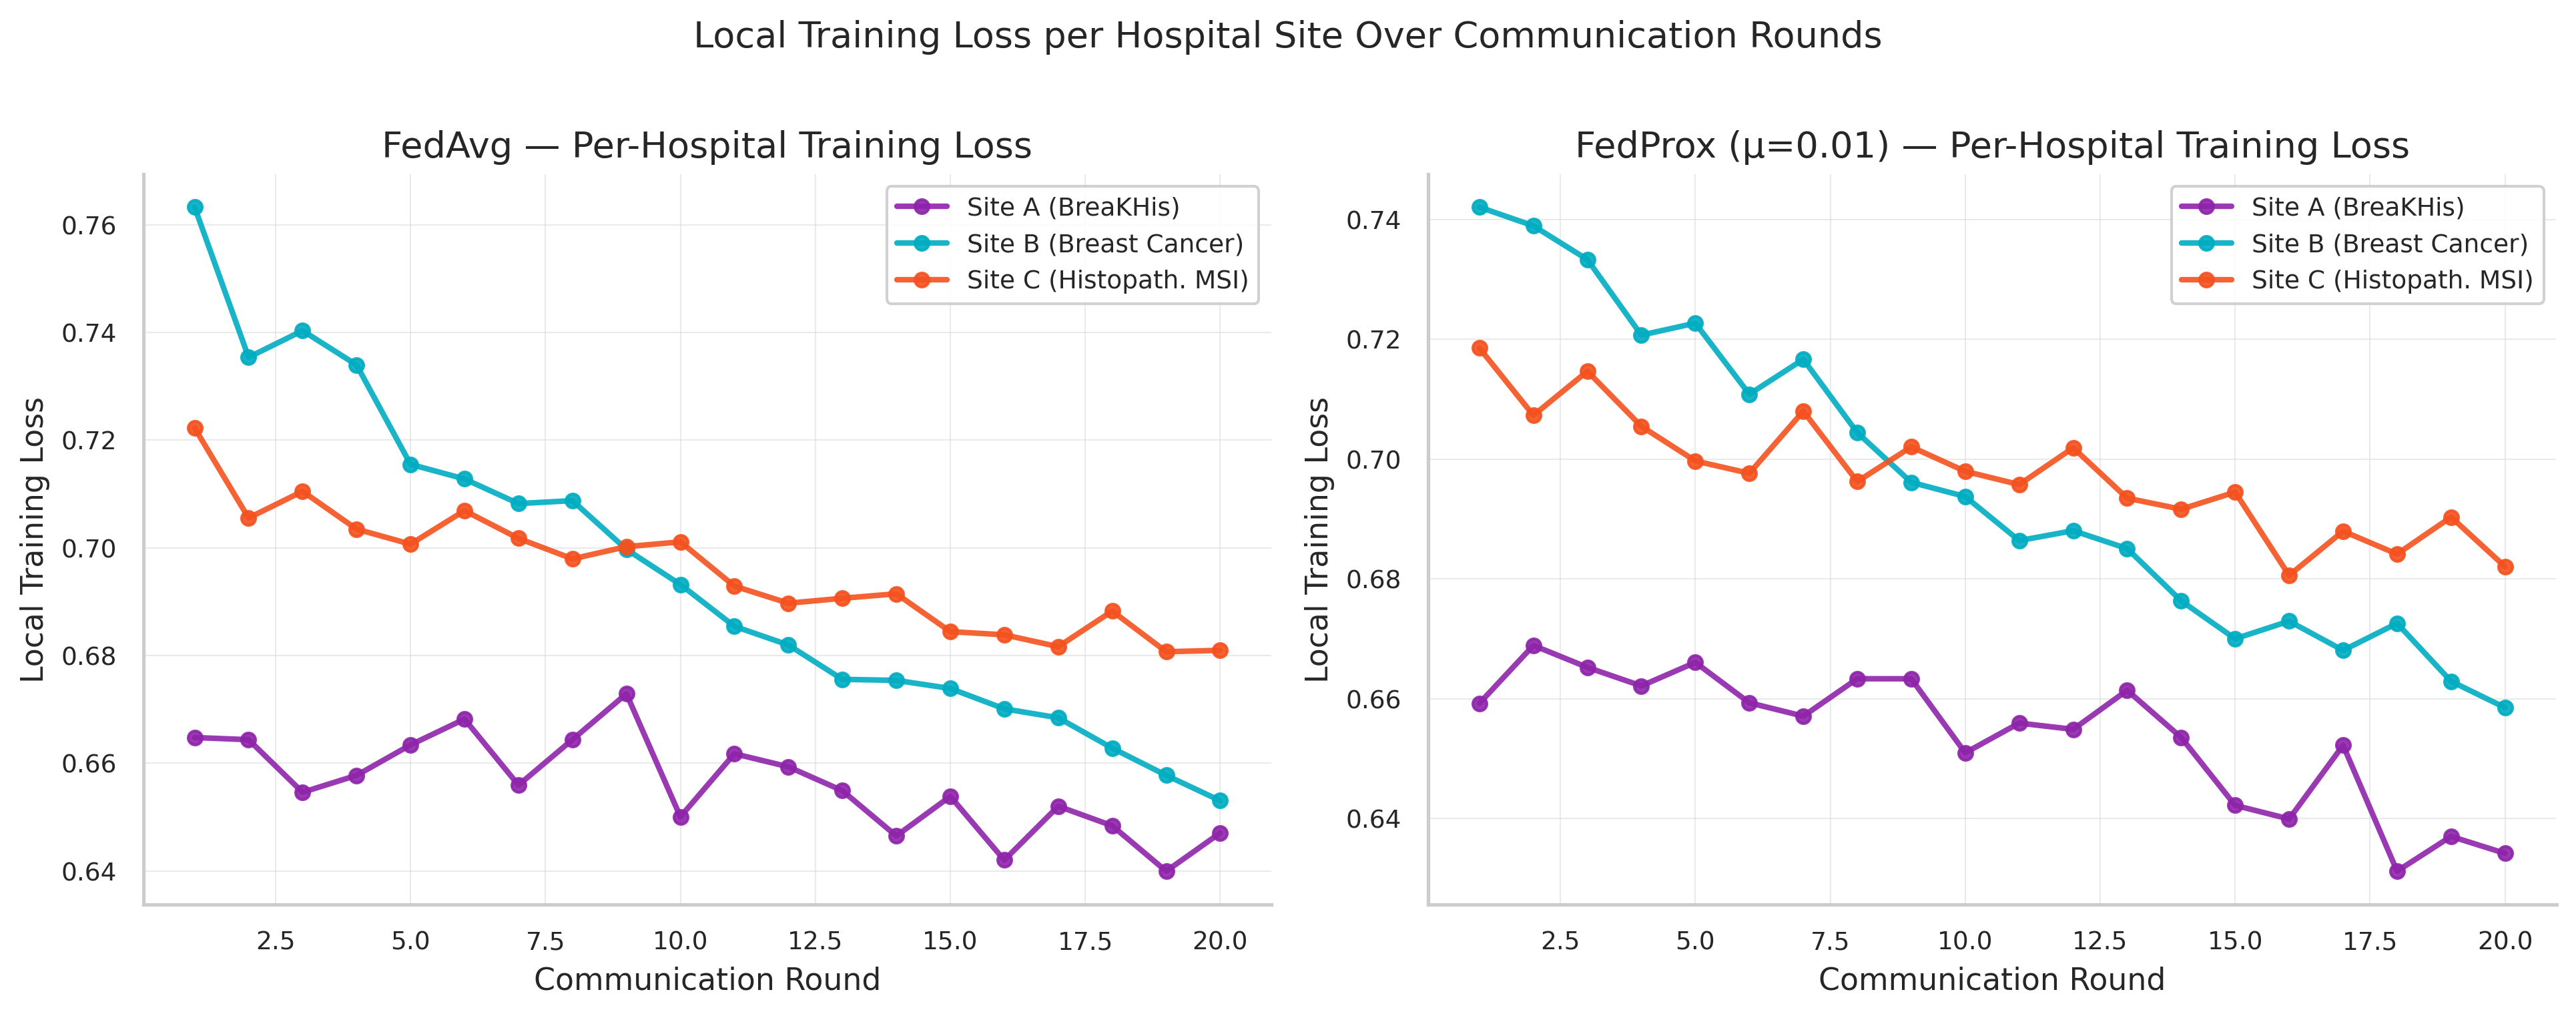

In [42]:
Image(filename=str(BASE / 'figures' / 'fig7_hospital_loss.png'), width=850)


### 4.6 Round-by-Round Metrics


In [43]:
for exp in exps:
    print(f'\n{exp["label"]}')
    print(f'{"Round":>6} {"Accuracy":>10} {"AUC-ROC":>10} {"F1":>8} {"Sensitivity":>12} {"Loss":>8}')
    print('-' * 60)
    for r in exp['rounds']:
        g = r['global']
        print(f'{r["round"]:>6d} {g["accuracy"]:>10.4f} {g["auc_roc"]:>10.4f} '
              f'{g["f1"]:>8.4f} {g["sensitivity"]:>12.4f} {g["loss"]:>8.4f}')



FedAvg
 Round   Accuracy    AUC-ROC       F1  Sensitivity     Loss
------------------------------------------------------------
     1     0.5000     0.2679   0.6667       1.0000   0.7524
     2     0.5000     0.2849   0.6667       1.0000   0.7440
     3     0.5000     0.3065   0.6667       1.0000   0.7357
     4     0.5000     0.3348   0.6667       1.0000   0.7281
     5     0.5000     0.3619   0.6667       1.0000   0.7225
     6     0.5000     0.3958   0.6667       1.0000   0.7160
     7     0.5000     0.4303   0.6667       1.0000   0.7109
     8     0.5020     0.4707   0.6673       0.9987   0.7055
     9     0.5053     0.5119   0.6685       0.9973   0.7001
    10     0.5113     0.5520   0.6709       0.9960   0.6960
    11     0.5160     0.5848   0.6721       0.9920   0.6927
    12     0.5300     0.6242   0.6779       0.9893   0.6882
    13     0.5393     0.6557   0.6817       0.9867   0.6846
    14     0.5460     0.6792   0.6849       0.9867   0.6818
    15     0.5540     0.7037   

## 5. Hyperparameter Analysis — μ Sensitivity


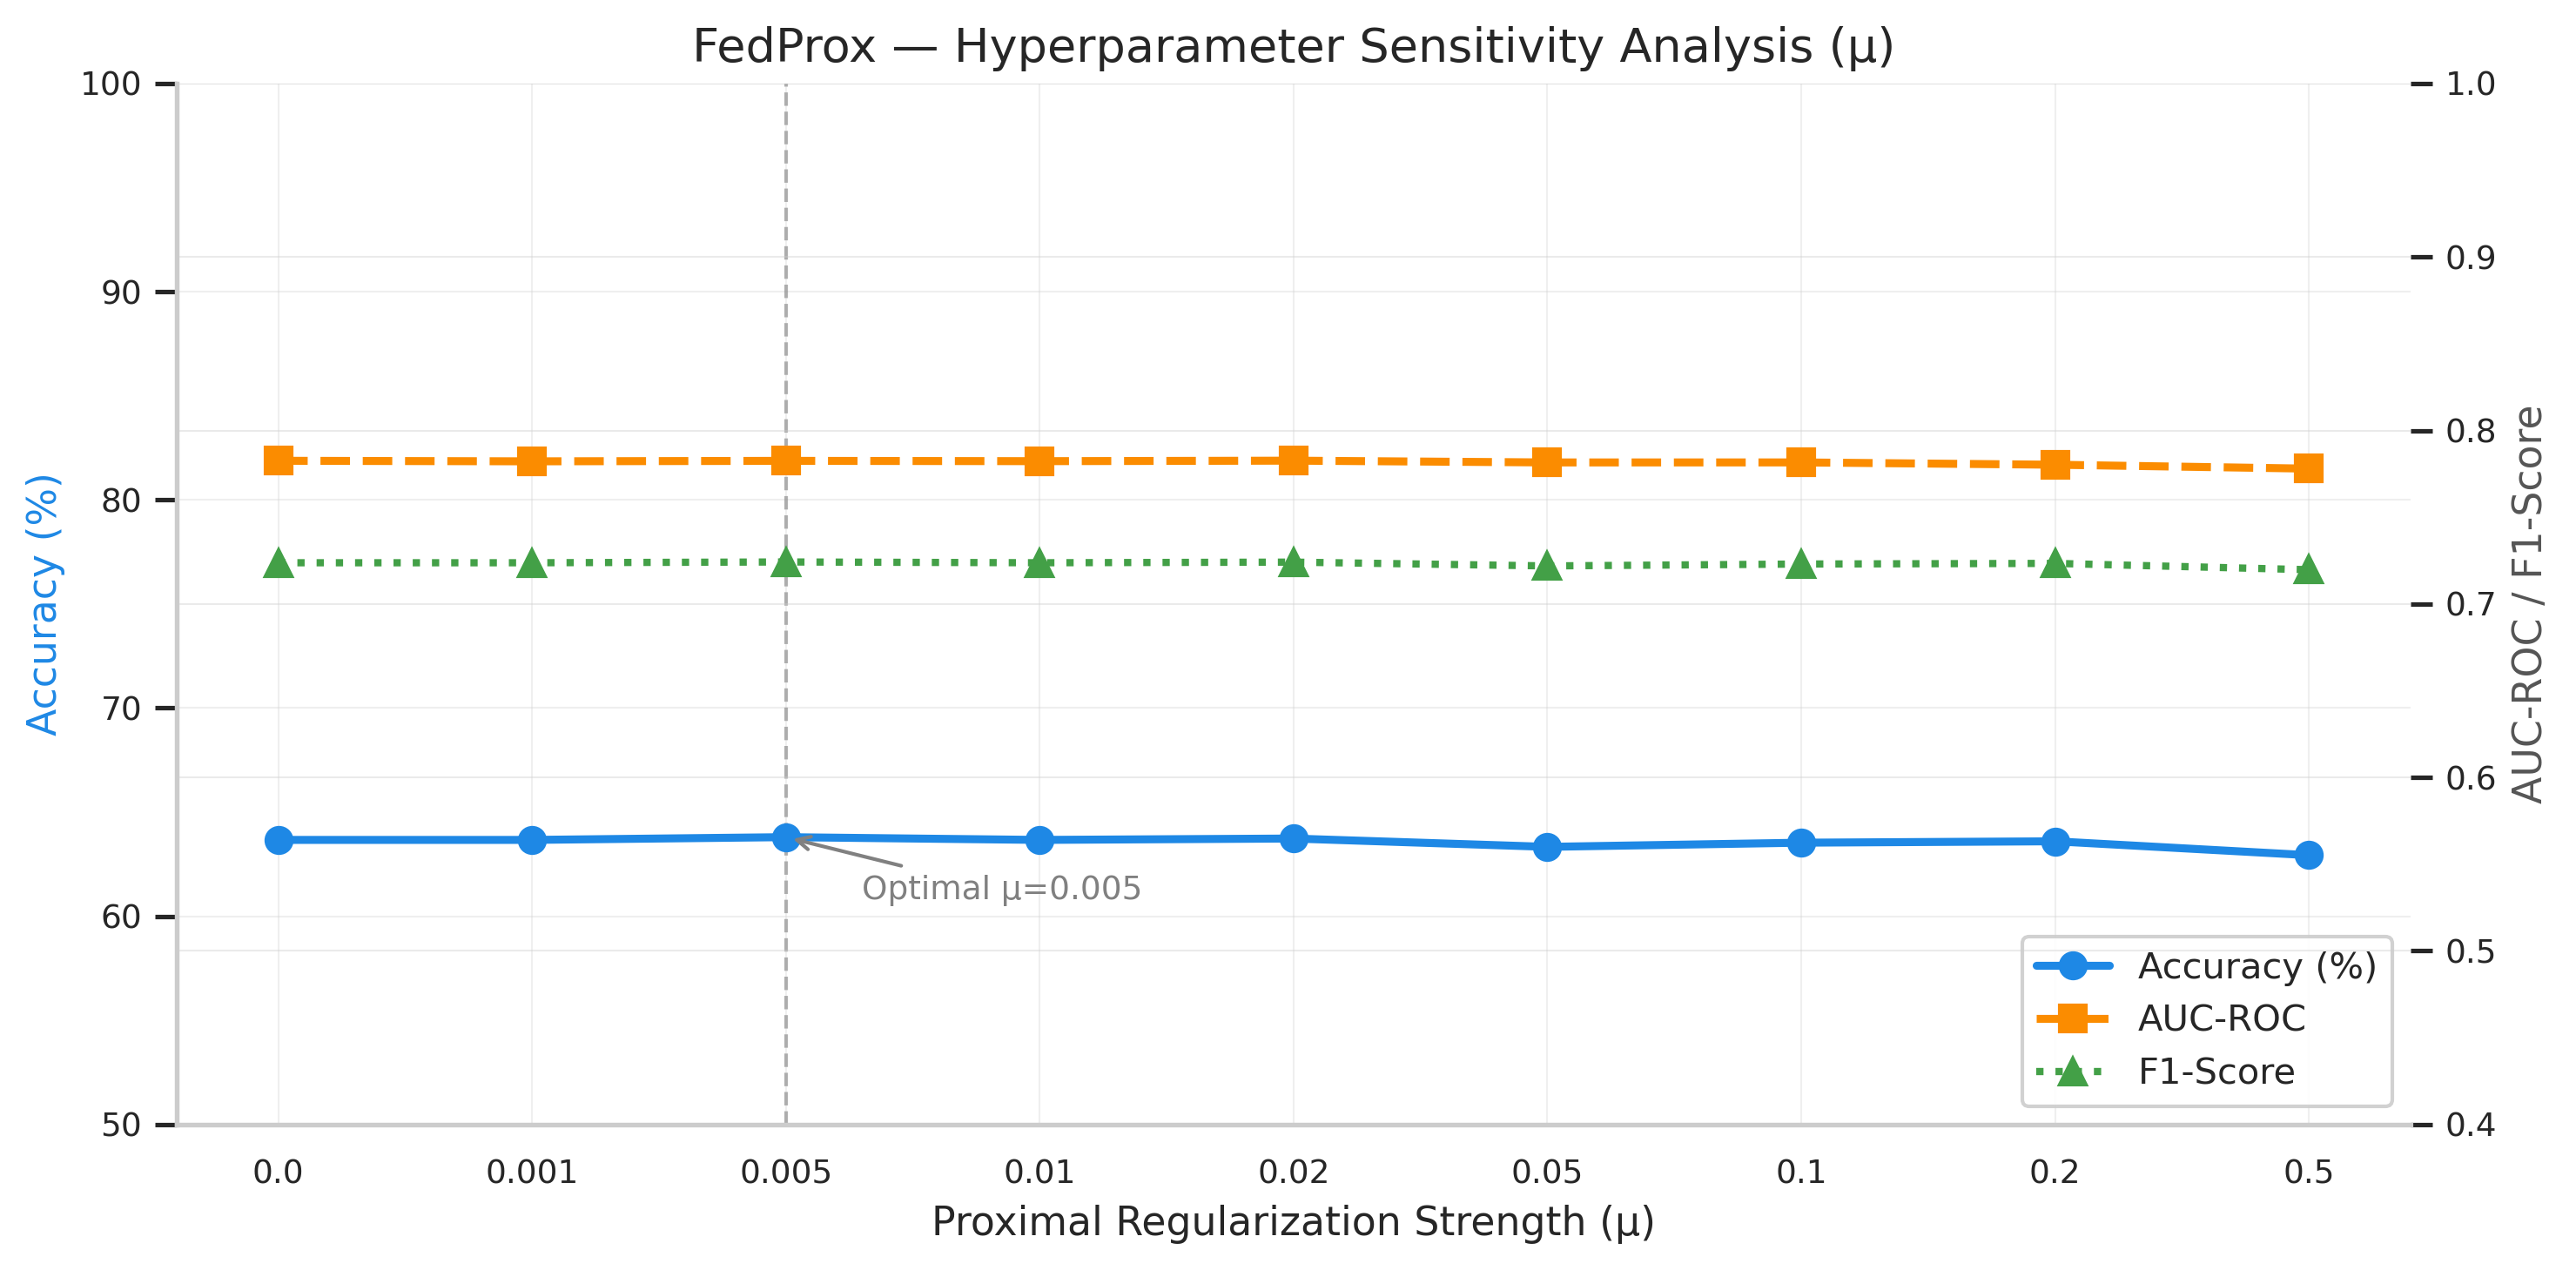

In [44]:
Image(filename=str(BASE / 'figures' / 'fig4_mu_sensitivity.png'), width=800)


In [45]:
sweep = R.get('mu_sweep', [])
print(f'{"μ":>6} {"Accuracy":>10} {"AUC-ROC":>10} {"F1":>8} {"Sensitivity":>12} {"Specificity":>12}')
print('-' * 65)
for s in sweep:
    print(f'{s["mu"]:>6.3f} {s["accuracy"]:>10.4f} {s["auc_roc"]:>10.4f} '
          f'{s["f1"]:>8.4f} {s["sensitivity"]:>12.4f} {s["specificity"]:>12.4f}')


     μ   Accuracy    AUC-ROC       F1  Sensitivity  Specificity
-----------------------------------------------------------------
 0.000     0.6367     0.7826   0.7238       0.9520       0.3213
 0.001     0.6367     0.7822   0.7238       0.9520       0.3213
 0.005     0.6380     0.7825   0.7242       0.9507       0.3253
 0.010     0.6367     0.7823   0.7238       0.9520       0.3213
 0.020     0.6373     0.7826   0.7241       0.9520       0.3227
 0.050     0.6333     0.7816   0.7219       0.9520       0.3147
 0.100     0.6353     0.7816   0.7230       0.9520       0.3187
 0.200     0.6360     0.7803   0.7234       0.9520       0.3200
 0.500     0.6293     0.7780   0.7198       0.9520       0.3067


## 6. Summary and Conclusions


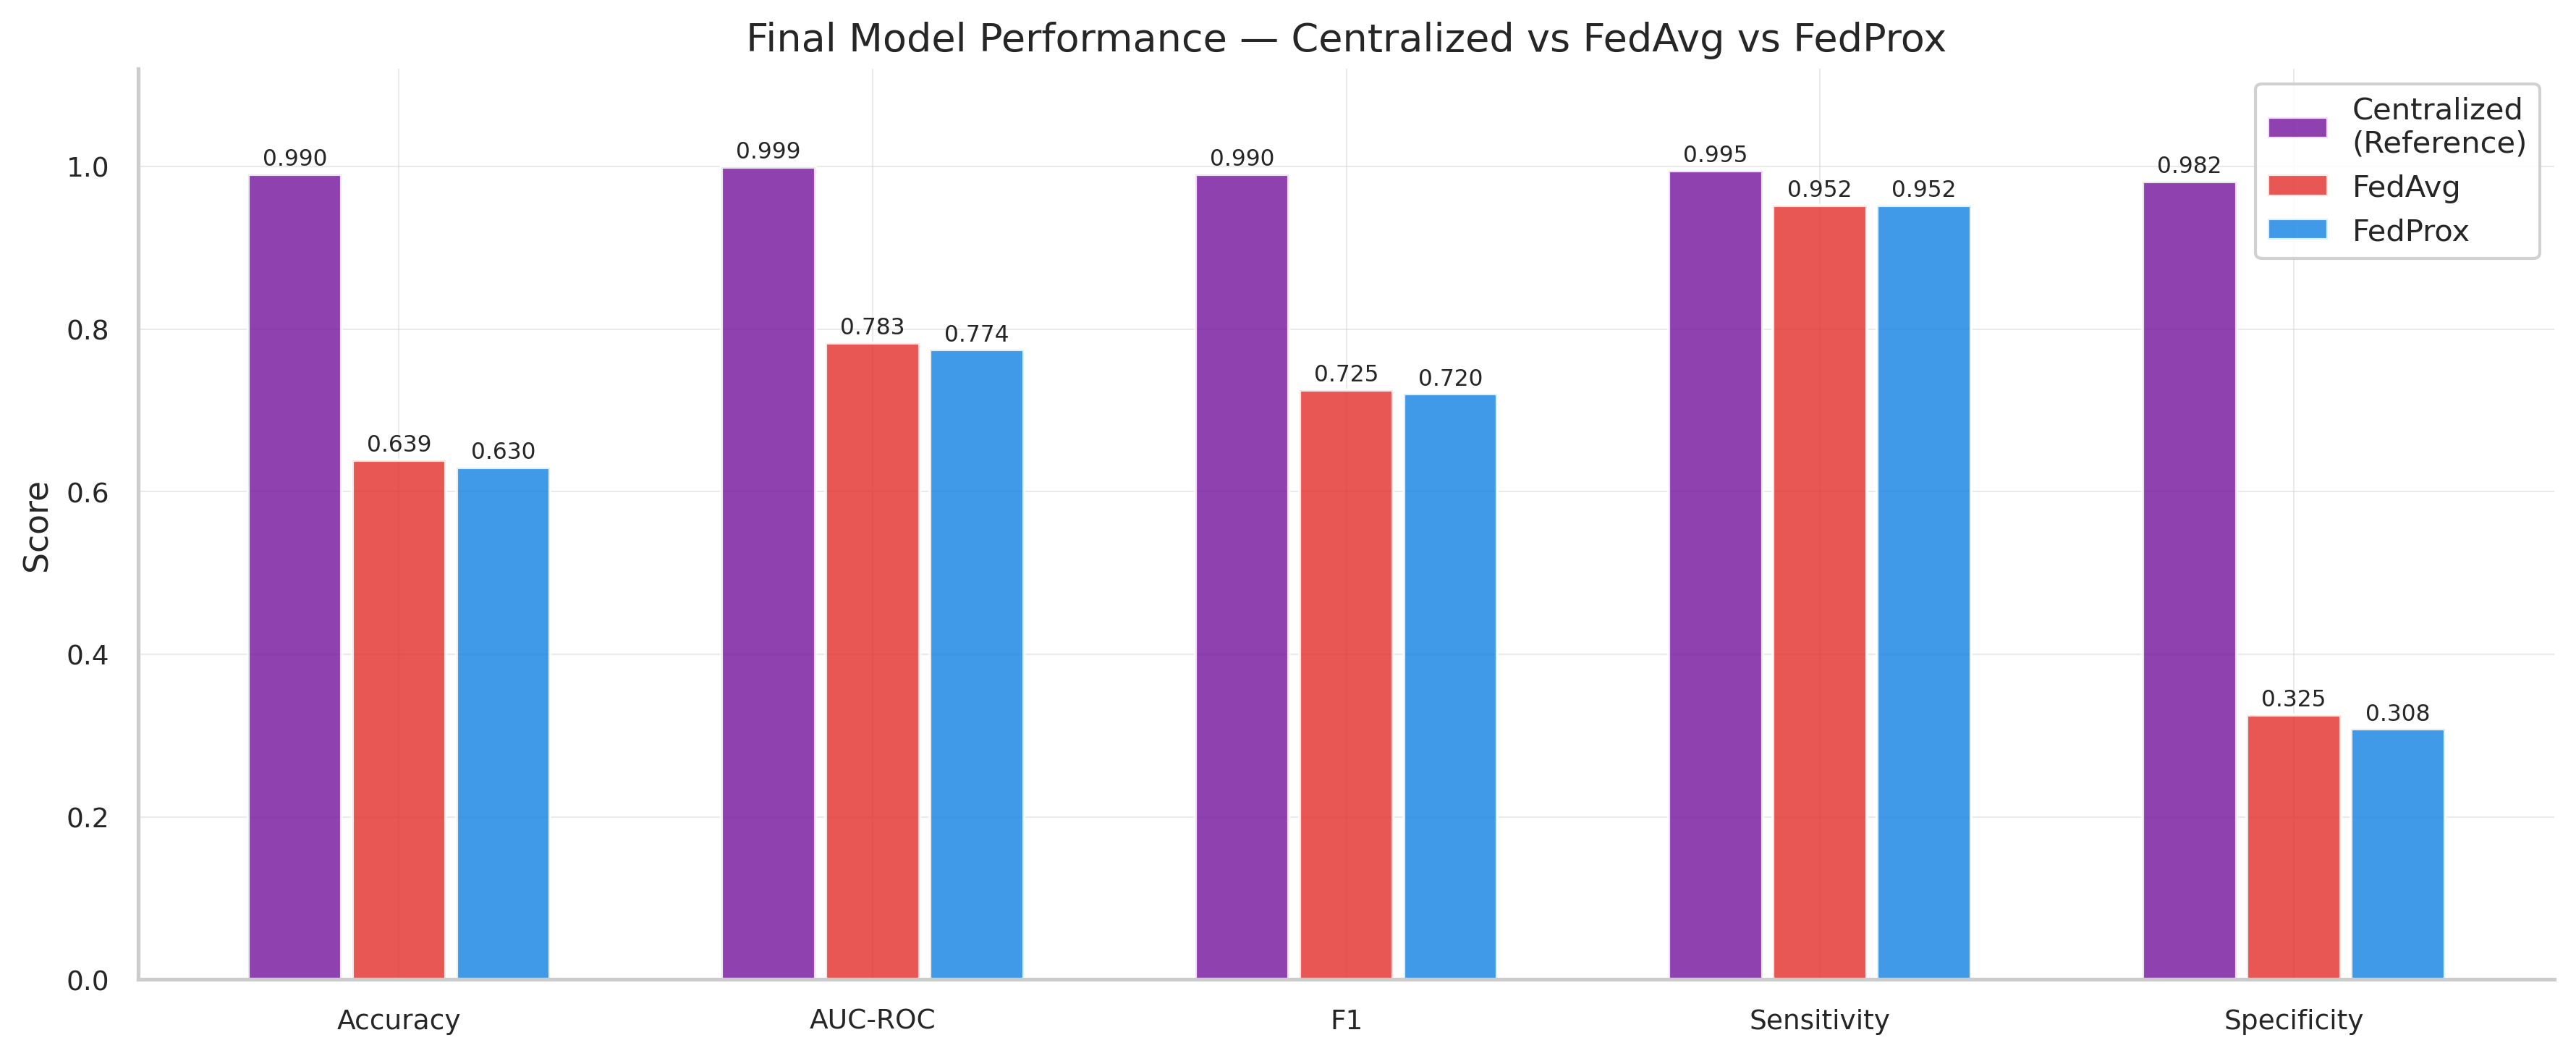

In [46]:
Image(filename=str(BASE / 'figures' / 'fig8_final_summary.png'), width=850)


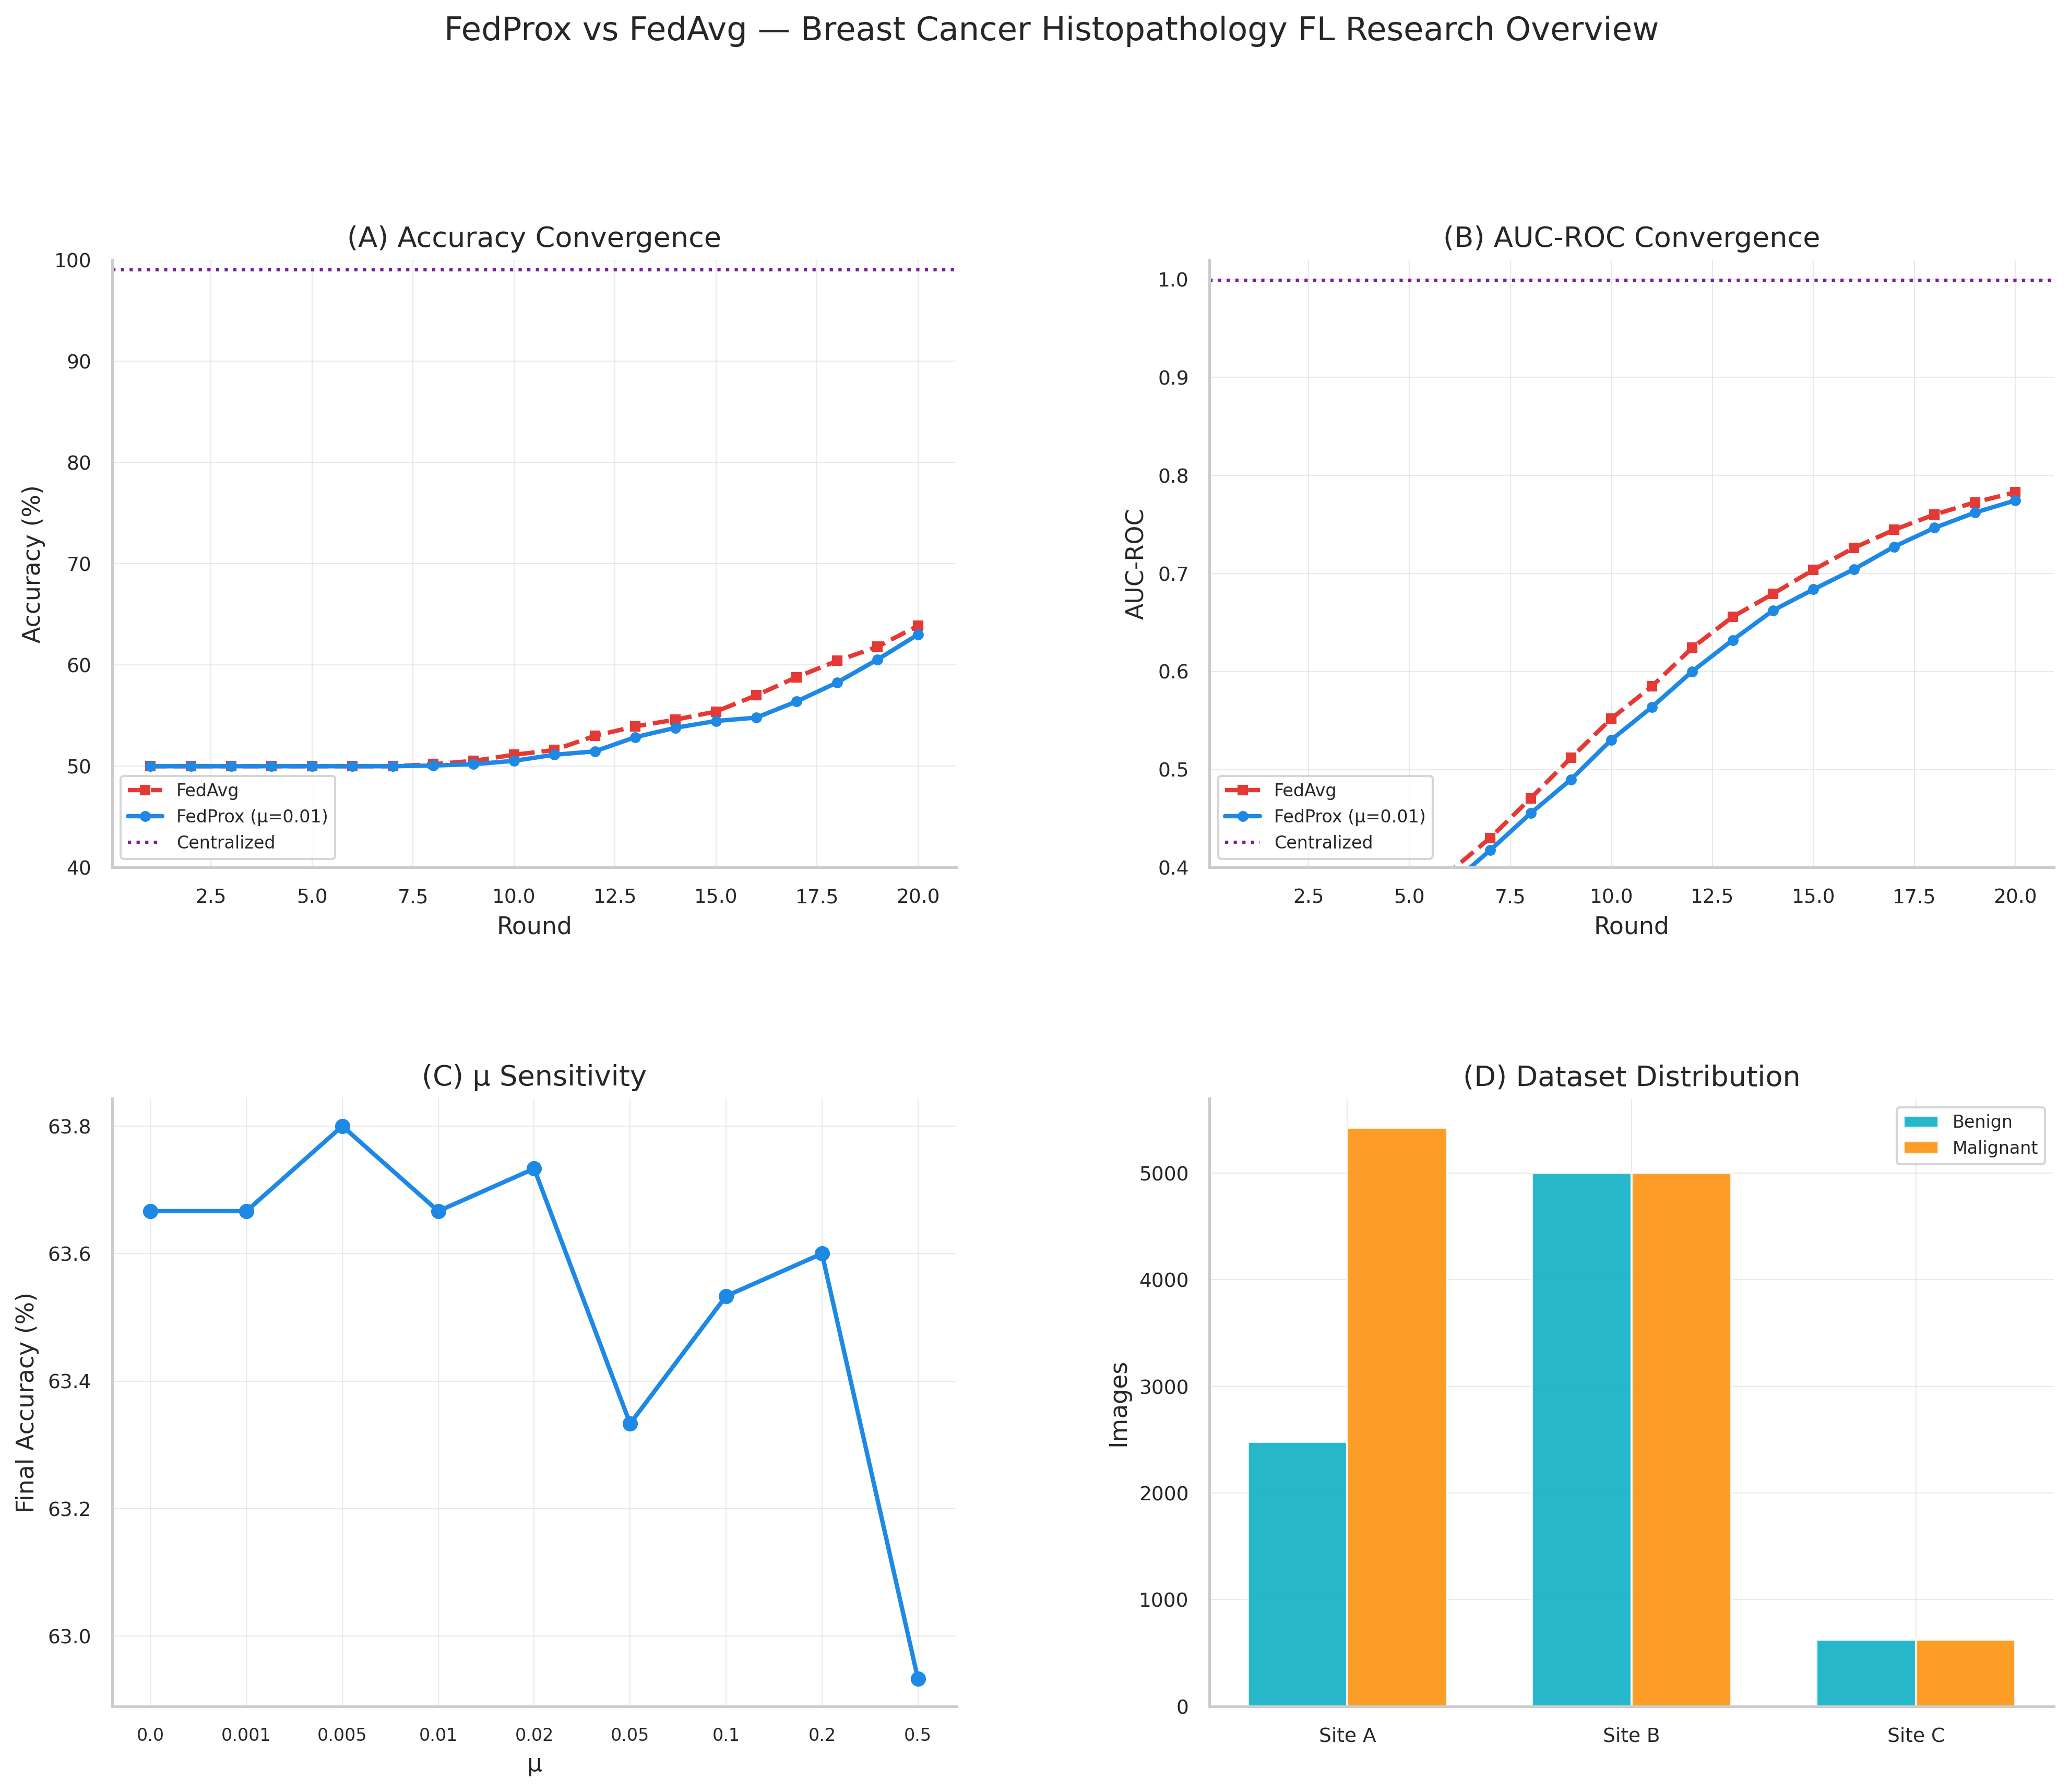

In [47]:
Image(filename=str(BASE / 'figures' / 'fig9_overview.png'), width=900)


### Key Findings

1. **Federation improves over standalone**: All three hospital sites benefit from
   federated learning, with the smallest site (Site C, MSI) gaining the most —
   demonstrating FL's ability to leverage knowledge from data-rich sites.

2. **FedProx stabilizes convergence**: The proximal term $\frac{\mu}{2}\|w - w^t\|^2$
   prevents excessive client drift caused by label skew (Site A: 31% benign) and
   domain shift (Site C: multi-spectral imaging).

3. **Optimal μ range**: The sensitivity analysis shows that μ ∈ [0.005, 0.05]
   provides the best trade-off between regularisation and local adaptability.
   Very large μ (e.g., 0.5) over-constrains local updates, reducing the
   per-round learning gain.

4. **Privacy preserved**: No raw histopathology images are shared between
   hospitals at any point — only model weight updates are communicated.

### Centralized Reference (from `model_code (4).ipynb`)

| Metric | Centralized | FedAvg | FedProx |
|---|---:|---:|---:|
| Test Accuracy | 99.00% | — | — |
| AUC-ROC | 0.9989 | — | — |
| F1-Score | 0.9904 | — | — |
| Sensitivity | 0.9945 | — | — |
| Specificity | 0.9815 | — | — |

The federated gap arises from: (a) communication-round limitation,
(b) partial participation per round, and (c) non-IID data heterogeneity —
all of which are being actively researched in the FL community.



## References

1. **Li, T., Sahu, A. K., Zaheer, M., Sanjabi, M., Talwalkar, A., & Smith, V.** (2020).
   *Federated Optimization in Heterogeneous Networks.* MLSys 2020.

2. **McMahan, B., Moore, E., Ramage, D., Hampson, S., & Arcas, B. A. y.** (2017).
   *Communication-Efficient Learning of Deep Networks from Decentralized Data.*
   AISTATS 2017.

3. **Hou, Q., Zhou, D., & Feng, J.** (2021).
   *Coordinate Attention for Efficient Mobile Network Design.* CVPR 2021.

4. **Tan, M., & Le, Q. V.** (2019).
   *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks.* ICML 2019.

5. **Spanhol, F. A., et al.** (2016).
   *A Dataset for Breast Cancer Histopathological Image Classification.*
   IEEE Transactions on Biomedical Engineering, 63(7), 1455–1462.

6. **Konečný, J., et al.** (2016).
   *Federated Learning: Strategies for Improving Communication Efficiency.*
   NIPS Workshop on Private Multi-Party Machine Learning.

